# IzzyViz Use Case 2: Exploring Tuned Model Attention Differences

This notebook demonstrates the **Explore** stage of IzzyViz for tuned-model comparison.

Research goal:

- Use one fixed QA prompt.
- Compare attention behavior across Qwen-family base, instruct, math, coder, and distilled variants.
- Identify not only visually interesting regions within each overview, but also **which same layer/head locations differ most from the base model**.

Workflow:

**Same Prompt -> Overview -> Same-Head Vector Comparison -> Difference × Salience Selection -> Representative Heads -> Hypotheses**

This notebook reads existing outputs from `workflow/rag_cluster/multi_model_single_prompt_cluster/`. It does not rerun model inference by default.

In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Image, IFrame, Markdown

from izzyviz import (
    select_distinctive_attention_heads_by_features,
    visualize_distinctive_attention_head_maps,
    visualize_representative_head_candidates,
    visualize_attention_matrix,
)

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != 'IzzyViz' and (PROJECT_DIR.parent / 'izzyviz').exists():
    PROJECT_DIR = PROJECT_DIR.parent

OUTPUT_ROOT = PROJECT_DIR / 'workflow' / 'rag_cluster' / 'multi_model_single_prompt_cluster'
SUMMARY_PATH = OUTPUT_ROOT / 'multi_model_summary.json'
USECASE_OUTPUT_DIR = PROJECT_DIR / 'workflow' / 'tuned_model_attention_exploration_outputs'
USECASE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BASE_MODEL = 'Qwen2.5-1.5B'
ORDERED_LABELS = [
    'Qwen2.5-1.5B',
    'Qwen2.5-1.5B-Instruct',
    'Qwen2.5-1.5B-Math',
    'Qwen2.5-1.5B-Math-Instruct',
    'Qwen2.5-1.5B-Coder',
    'DeepSeek-R1-Distill-Qwen-1.5B',
]

print('Project:', PROJECT_DIR)
print('Outputs:', OUTPUT_ROOT)
print('Summary exists:', SUMMARY_PATH.exists())

Project: /home/cuizhouying/IzzyViz
Outputs: /home/cuizhouying/IzzyViz/workflow/rag_cluster/multi_model_single_prompt_cluster
Summary exists: True


## 1. Load Multi-Model Metadata and Raw Head Features

The input prompt is fixed across all model variants. Therefore, for every model we can compare the same `(layer, head)` location against the base model.

This notebook uses raw per-head feature vectors saved from the attention tensors, not overview screenshots. Each head vector contains the same metrics used by IzzyViz clustering:

- concentration
- entropy
- variance
- threshold mass
- top-percent mass
- low-range dependency
- long-range dependency

The comparison is therefore:

`same prompt, same analyzed token region, same layer, same head, feature-vector distance from base`

In [2]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def safe_name(value):
    return re.sub(r'[^a-zA-Z0-9_]+', '_', str(value)).strip('_')

def load_feature_bundle(model_dir):
    path = Path(model_dir) / 'head_features.npz'
    if not path.exists():
        raise FileNotFoundError(
            f'Missing {path}. Re-run workflow/rag_cluster/run_single_prompt_multi_model_cluster.py '
            'after the feature-saving update.'
        )
    data = np.load(path, allow_pickle=True)
    head_infos = np.asarray(data['head_infos'], dtype=int)
    if 'features_layer_head' in data:
        features = data['features_layer_head']
        features_scaled = data['features_scaled_layer_head']
    else:
        # Backward compatibility with older experiment outputs that saved flat
        # [layer*head, feature] arrays. The head order is produced by
        # cluster_attention_heads as layer-major, head-minor.
        num_layers = int(head_infos[:, 0].max()) + 1
        num_heads = int(head_infos[:, 1].max()) + 1
        features = data['features'].reshape(num_layers, num_heads, -1)
        features_scaled = data['features_scaled'].reshape(num_layers, num_heads, -1)
    return {
        'features': features,
        'features_scaled': features_scaled,
        'feature_names': [str(x) for x in data['feature_names'].tolist()],
        'head_infos': head_infos,
        'path': path,
    }

summary = load_json(SUMMARY_PATH)
rows = []
feature_bundles = {}
for item in summary:
    if 'error' in item:
        rows.append({'model_label': item.get('model_label'), 'model_id': item.get('model_id'), 'error': item.get('error')})
        continue
    summary_path = Path(item['output_paths']['summary'])
    if not summary_path.exists():
        summary_path = OUTPUT_ROOT / Path(summary_path).parent.name / 'run_summary.json'
    model_dir = summary_path.parent
    bundle = load_feature_bundle(model_dir)
    feature_bundles[item['model_label']] = bundle
    run_summary = load_json(summary_path)
    cluster_sizes = {str(k): int(v) for k, v in run_summary.get('cluster_sizes', {}).items()}
    total_heads = sum(cluster_sizes.values()) or np.nan
    probs = np.array(list(cluster_sizes.values()), dtype=float) / total_heads
    cluster_entropy = float(-(probs * np.log2(probs + 1e-12)).sum()) if total_heads else np.nan
    largest_cluster_fraction = float(max(cluster_sizes.values()) / total_heads) if total_heads else np.nan
    reps = run_summary.get('representatives', [])
    rep_layers = [int(r['layer']) for r in reps]
    rows.append({
        'model_label': item['model_label'],
        'model_id': item['model_id'],
        'seq_len': item.get('seq_len'),
        'model_dir': model_dir,
        'feature_path': bundle['path'],
        'feature_names': bundle['feature_names'],
        'cluster_entropy': cluster_entropy,
        'largest_cluster_fraction': largest_cluster_fraction,
        'rep_layer_mean': float(np.mean(rep_layers)) if rep_layers else np.nan,
        'rep_layer_span': int(max(rep_layers) - min(rep_layers)) if rep_layers else np.nan,
        'representatives': reps,
        'overview_merge': model_dir / 'overview_merge_tokens.png',
        'overview_no_merge': model_dir / 'overview_no_merge.png',
        'pca': model_dir / 'pca_scatter.png',
        'detail_heatmaps': sorted(model_dir.glob('cluster_*_L*_H*.pdf')),
    })

model_df = pd.DataFrame(rows).set_index('model_label').loc[ORDERED_LABELS].reset_index()
print('Feature names:', feature_bundles[BASE_MODEL]['feature_names'])
display(model_df[['model_label', 'seq_len', 'cluster_entropy', 'largest_cluster_fraction', 'rep_layer_mean', 'rep_layer_span', 'feature_path']])

Feature names: ['concentration', 'entropy', 'variance', 'threshold_mass', 'top_percent_mass', 'low_range', 'long_range']


,model_label,seq_len,cluster_entropy,largest_cluster_fraction,rep_layer_mean,rep_layer_span,feature_path
0,Qwen2.5-1.5B,243,1.596989,0.610119,16.8,17,/home/cuizhouying/IzzyViz/workflow/rag_cluster/multi_model_single_prompt_cluster/Qwen2_5-1_5B/head_features.npz
1,Qwen2.5-1.5B-Instruct,243,1.543421,0.616071,14.0,19,/home/cuizhouying/IzzyViz/workflow/rag_cluster/multi_model_single_prompt_cluster/Qwen2_5-1_5B-Instruct/head_features.npz
2,Qwen2.5-1.5B-Math,243,1.828493,0.502976,15.8,25,/home/cuizhouying/IzzyViz/workflow/rag_cluster/multi_model_single_prompt_cluster/Qwen2_5-1_5B-Math/head_features.npz
3,Qwen2.5-1.5B-Math-Instruct,243,1.000598,0.812500,18.0,21,/home/cuizhouying/IzzyViz/workflow/rag_cluster/multi_model_single_prompt_cluster/Qwen2_5-1_5B-Math-Instruct/head_features.npz
4,Qwen2.5-1.5B-Coder,243,0.993666,0.818452,19.4,9,/home/cuizhouying/IzzyViz/workflow/rag_cluster/multi_model_single_prompt_cluster/Qwen2_5-1_5B-Coder/head_features.npz
5,DeepSeek-R1-Distill-Qwen-1.5B,243,1.339768,0.711310,14.4,17,/home/cuizhouying/IzzyViz/workflow/rag_cluster/multi_model_single_prompt_cluster/DeepSeek-R1-Distill-Qwen-1_5B/head_features.npz


## 2. Observe: IzzyViz Overview Across the Qwen Family

The overview remains the first visual step. It gives a global view of Layer × Head attention behavior before quantitative selection.

Manual observations to consider:

- Base and Instruct appear visually similar.
- Math and Math-Instruct show stronger local changes than Base vs Instruct.
- DeepSeek-R1-Distill-Qwen shows distinctive structures in several low-layer heads.
- Coder remains broadly similar to the base model.
- Attention sinks and recurring vertical structures appear across variants, suggesting a shared Qwen-family fingerprint.

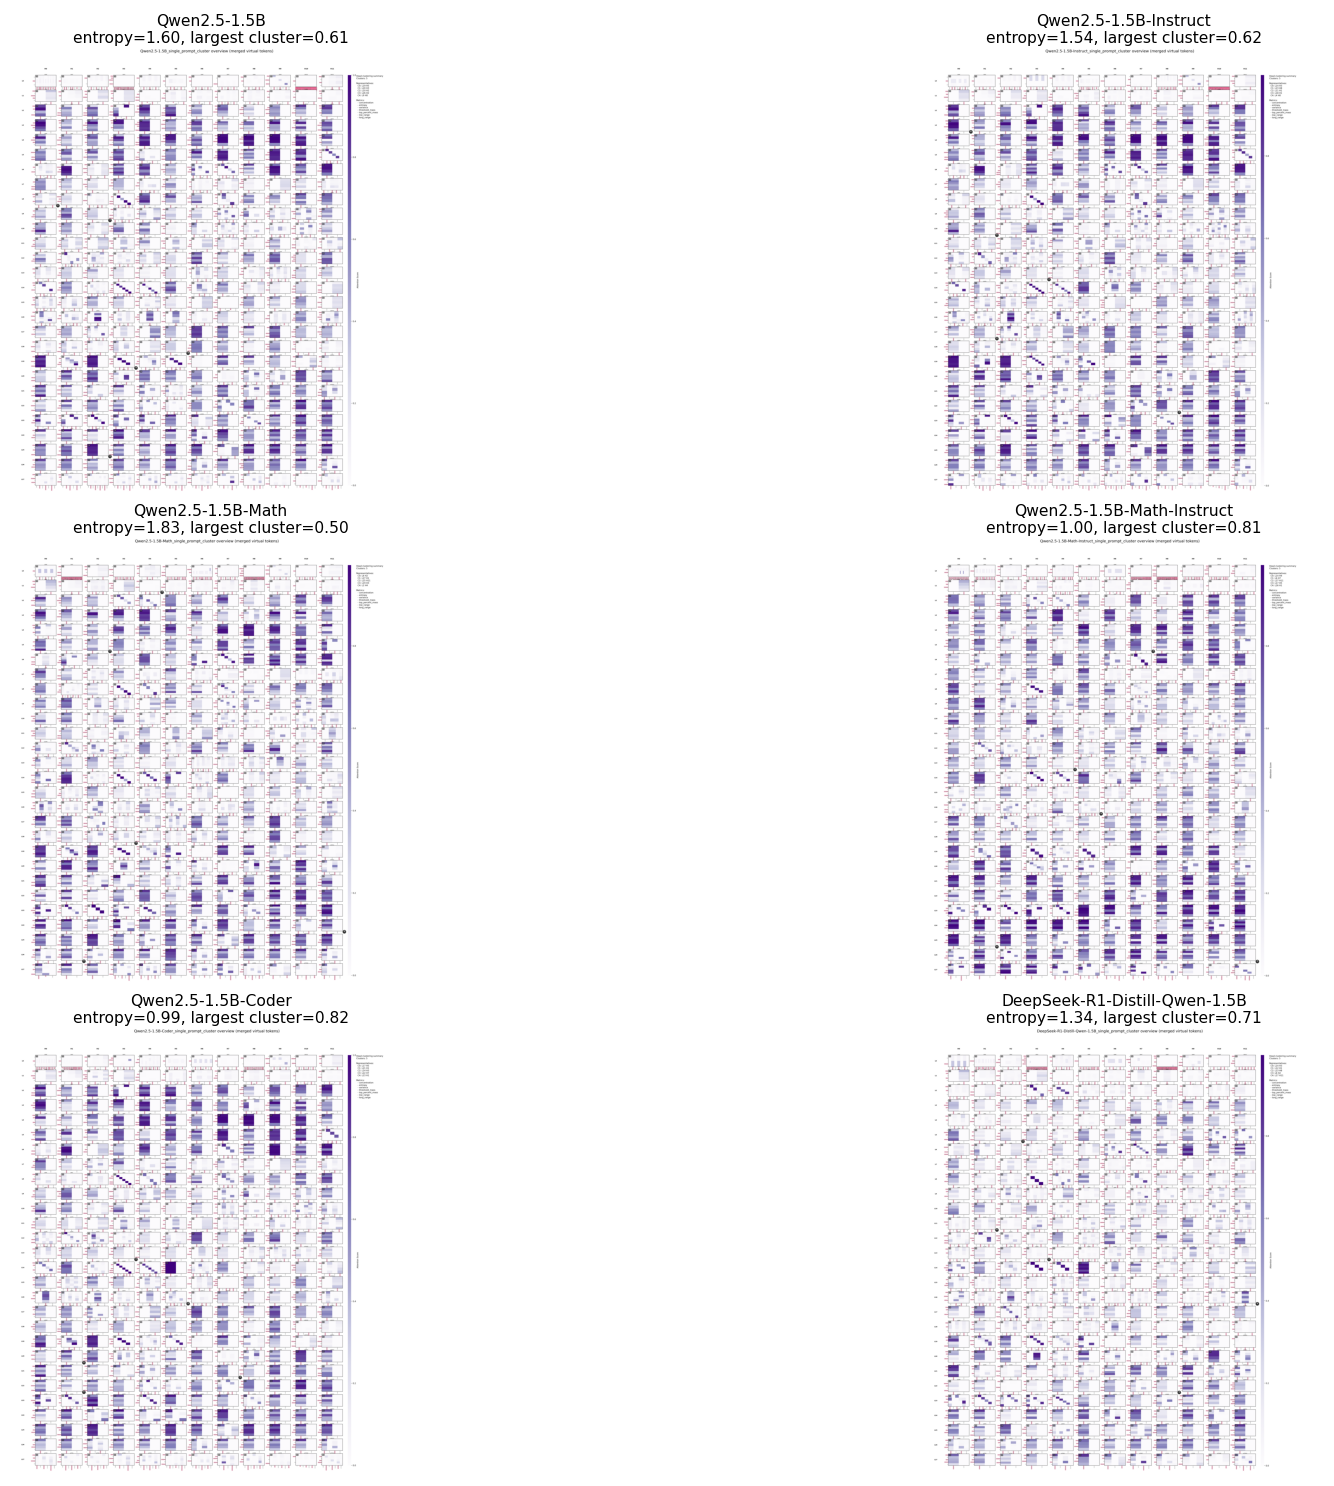

In [3]:
overview_cols = 2
overview_rows = int(np.ceil(len(model_df) / overview_cols))
fig, axes = plt.subplots(overview_rows, overview_cols, figsize=(13, 10.5), constrained_layout=True)
axes = np.asarray(axes).reshape(overview_rows, overview_cols)

for idx, (_, row) in enumerate(model_df.iterrows()):
    ax = axes[idx // overview_cols, idx % overview_cols]
    img = plt.imread(row['overview_merge'])
    ax.imshow(img)
    ax.set_title(
        f"{row['model_label']}\nentropy={row['cluster_entropy']:.2f}, largest cluster={row['largest_cluster_fraction']:.2f}",
        fontsize=8,
        pad=3,
    )
    ax.axis('off')

for idx in range(len(model_df), overview_rows * overview_cols):
    axes[idx // overview_cols, idx % overview_cols].axis('off')

plt.show()


## 3. Select: Same-Layer Same-Head Vector Differences from Base

This is the main tuned-model comparison step.

For every target model and every `(layer, head)`, IzzyViz compares:

`target_features[layer, head, :]` vs `base_features[layer, head, :]`

The vector distance is the **relative difference**. The norm of the target head vector is the **absolute salience**. IzzyViz then ranks heads by:

`combined_score = normalized_relative_difference × normalized_absolute_salience`

This directly addresses the issue that a head can be different but weak, or strong but not different. The selected heads are both.

In [4]:
base_features = feature_bundles[BASE_MODEL]['features']
feature_names = feature_bundles[BASE_MODEL]['feature_names']
comparison_results = {}
comparison_rows = []

for model_label in ORDERED_LABELS:
    if model_label == BASE_MODEL:
        continue
    target_features = feature_bundles[model_label]['features']
    out_dir = USECASE_OUTPUT_DIR / safe_name(model_label) / 'feature_difference_from_base'
    result = select_distinctive_attention_heads_by_features(
        target_features=target_features,
        reference_features=base_features,
        feature_names=feature_names,
        top_k=12,
        scale='robust',
        distance_metric='euclidean',
        salience_method='norm',
        output_dir=out_dir,
        run_name=f'{model_label}_vs_{BASE_MODEL}',
        plot_heatmaps=True,
    )
    comparison_results[model_label] = result
    top = result['top_records'][0]
    comparison_rows.append({
        'model_label': model_label,
        'mean_same_head_distance': float(np.mean(result['relative_scores'])),
        'max_same_head_distance': float(np.max(result['relative_scores'])),
        'mean_target_salience': float(np.mean(result['salience_scores'])),
        'top_layer': top['layer'],
        'top_head': top['head'],
        'top_combined_score': top['combined_score'],
        'top_relative_norm': top['relative_score_normalized'],
        'top_salience_norm': top['salience_score_normalized'],
        'combined_heatmap': result['output_paths']['combined_distinctive_score_heatmap'],
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('mean_same_head_distance', ascending=False)
display(comparison_df[['model_label', 'mean_same_head_distance', 'max_same_head_distance', 'top_layer', 'top_head', 'top_combined_score', 'top_relative_norm', 'top_salience_norm']])

,model_label,mean_same_head_distance,max_same_head_distance,top_layer,top_head,top_combined_score,top_relative_norm,top_salience_norm
2,Qwen2.5-1.5B-Math-Instruct,1.831169,11.649652,23,4,0.553712,0.981142,0.564354
4,DeepSeek-R1-Distill-Qwen-1.5B,1.681120,11.732197,23,4,0.430619,0.764445,0.563310
1,Qwen2.5-1.5B-Math,1.341912,9.998991,23,4,0.393472,0.762937,0.515734
3,Qwen2.5-1.5B-Coder,0.992669,14.570876,23,4,0.465319,0.762918,0.609920
0,Qwen2.5-1.5B-Instruct,0.488304,7.753872,25,7,0.404931,0.597414,0.677805


## 4. Difference Maps in IzzyViz Select Style

The map below is a library-generated Select-stage visualization. Each row is a target model compared against the base model, and each cell is the combined difference × salience score for the same `(layer, head)` location.

These maps are computed from raw attention-derived feature vectors, not screenshot pixels. The base-vs-base zero map is omitted.

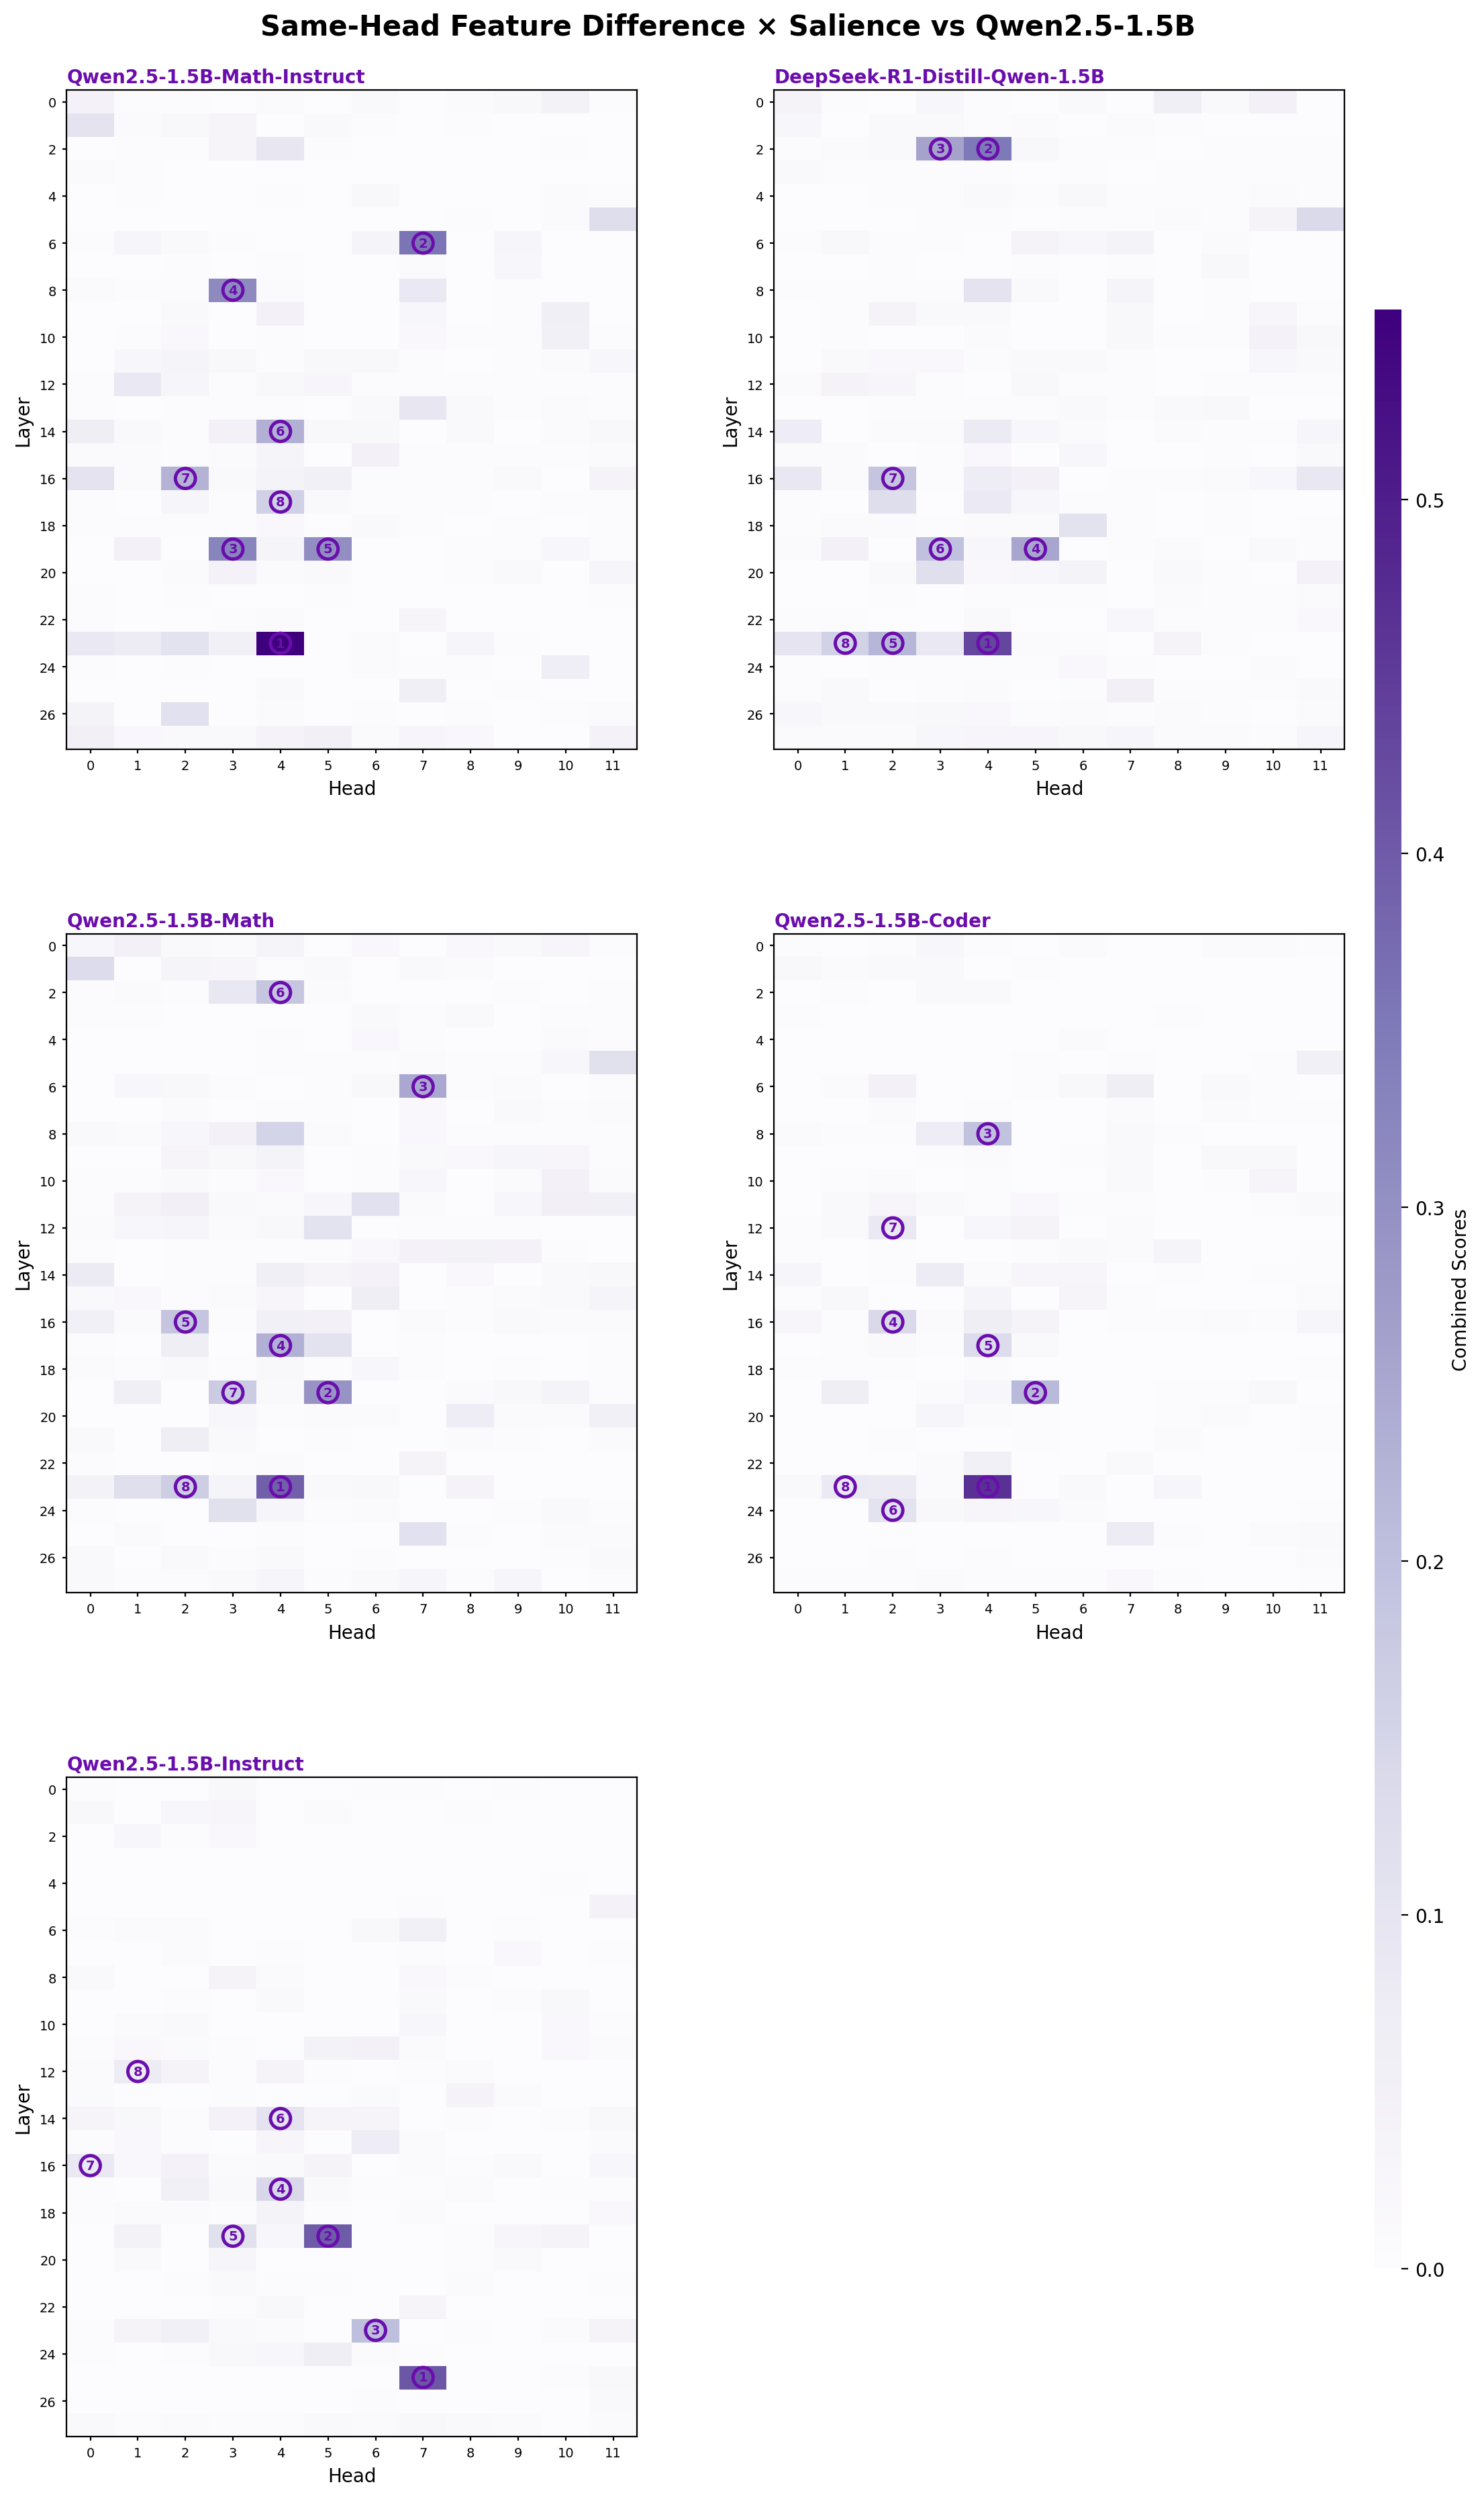

### Qwen2.5-1.5B-Math-Instruct vs Qwen2.5-1.5B: top distinctive heads

,rank,layer,head,combined_score,relative_score_normalized,salience_score_normalized,relative_score,salience_score
0,1,23,4,0.553712,0.981142,0.564354,11.432045,15.213517
1,2,6,7,0.358848,0.499691,0.718139,5.876488,19.262107
2,3,19,3,0.326272,0.471282,0.692308,5.548663,18.582068
3,4,8,3,0.312740,0.386366,0.809441,4.568803,21.665758
4,5,19,5,0.302893,0.603919,0.501545,7.079197,13.559976
5,6,14,4,0.229525,0.508610,0.451279,5.979401,12.236653
6,7,16,2,0.227044,0.821130,0.276502,9.585640,7.635433
7,8,17,4,0.160191,0.916156,0.174851,10.682164,4.959320


### DeepSeek-R1-Distill-Qwen-1.5B vs Qwen2.5-1.5B: top distinctive heads

,rank,layer,head,combined_score,relative_score_normalized,salience_score_normalized,relative_score,salience_score
0,1,23,4,0.430619,0.764445,0.563310,9.007863,12.072016
1,2,2,4,0.351000,0.840454,0.417631,9.886950,9.045461
2,3,2,3,0.259589,0.483525,0.536866,5.758865,11.522642
3,4,19,5,0.251297,1.000000,0.251297,11.732197,5.589781
4,5,23,2,0.219814,0.526522,0.417483,6.256145,9.042390
5,6,19,3,0.198814,0.255045,0.779527,3.116355,16.564063
6,7,16,2,0.186196,0.482287,0.386069,5.744547,8.389732
7,8,23,1,0.156809,0.310607,0.504847,3.758965,10.857421


### Qwen2.5-1.5B-Math vs Qwen2.5-1.5B: top distinctive heads

,rank,layer,head,combined_score,relative_score_normalized,salience_score_normalized,relative_score,salience_score
0,1,23,4,0.393472,0.762937,0.515734,7.647562,10.526105
1,2,19,5,0.290537,1.000000,0.290537,9.998991,6.048402
2,3,6,7,0.248094,0.363667,0.682202,3.687208,13.836082
3,4,17,4,0.230004,0.836581,0.274933,8.378041,5.738134
4,5,16,2,0.187057,0.466823,0.400703,4.710412,8.238886
5,6,2,4,0.183890,0.658922,0.279077,6.615848,5.820541
6,7,19,3,0.172289,0.220903,0.779932,2.271138,15.779301
7,8,23,2,0.167957,0.212205,0.791488,2.184859,16.009073


### Qwen2.5-1.5B-Coder vs Qwen2.5-1.5B: top distinctive heads

,rank,layer,head,combined_score,relative_score_normalized,salience_score_normalized,relative_score,salience_score
0,1,23,4,0.465319,0.762918,0.609920,11.121306,14.284634
1,2,19,5,0.214022,0.456942,0.468378,6.669320,11.013243
2,3,8,4,0.196715,0.502155,0.391740,7.327182,9.241946
3,4,16,2,0.139300,0.345305,0.403412,5.044987,9.511709
4,5,17,4,0.131252,0.346480,0.378815,5.062092,8.943200
5,6,24,2,0.106476,0.394889,0.269634,5.766446,6.419769
6,7,12,2,0.083081,0.233340,0.356053,3.415885,8.417117
7,8,23,1,0.080750,0.187060,0.431681,2.742509,10.165083


### Qwen2.5-1.5B-Instruct vs Qwen2.5-1.5B: top distinctive heads

,rank,layer,head,combined_score,relative_score_normalized,salience_score_normalized,relative_score,salience_score
0,1,25,7,0.404931,0.597414,0.677805,4.637941,13.373036
1,2,19,5,0.397974,1.000000,0.397974,7.753872,7.962021
2,3,23,6,0.202174,0.533499,0.378959,4.143250,7.594320
3,4,17,4,0.141115,0.267222,0.528082,2.082321,10.477871
4,5,19,3,0.113540,0.133463,0.850729,1.047047,16.716820
5,6,14,4,0.102293,0.166367,0.614865,1.301723,12.155982
6,7,16,0,0.083481,0.248557,0.335864,1.937854,6.761002
7,8,12,1,0.075276,0.161272,0.466768,1.262285,9.292258


In [5]:
diff_map_result = visualize_distinctive_attention_head_maps(
    comparison_results,
    model_order=list(comparison_df['model_label']),
    score_key='combined_scores',
    top_n=8,
    title='Same-Head Feature Difference × Salience vs Qwen2.5-1.5B',
    output_dir=USECASE_OUTPUT_DIR,
    filename='same_head_feature_difference_select_map.png',
    layout='grid',
    ncols=2,
    panel_width=5.6,
    panel_height=6.4,
    tick_every=2,
)

show_path = diff_map_result['output_path']
display(Image(filename=show_path, width=1100))

for _, row in comparison_df.iterrows():
    display(Markdown(f"### {row['model_label']} vs {BASE_MODEL}: top distinctive heads"))
    records = comparison_results[row['model_label']]['top_records'][:8]
    display(pd.DataFrame(records)[[
        'rank', 'layer', 'head', 'combined_score',
        'relative_score_normalized', 'salience_score_normalized',
        'relative_score', 'salience_score'
    ]])


## 5. Representative Heads and Candidate Heatmaps

This library-generated view summarizes clustering representatives and highlights representatives that also appear among the top distinctive heads.

It is useful because a head can be:

- distinctive relative to the base model;
- representative of a broader cluster within the target model;
- or both.

Heads that satisfy both criteria are strong candidates for detailed inspection.

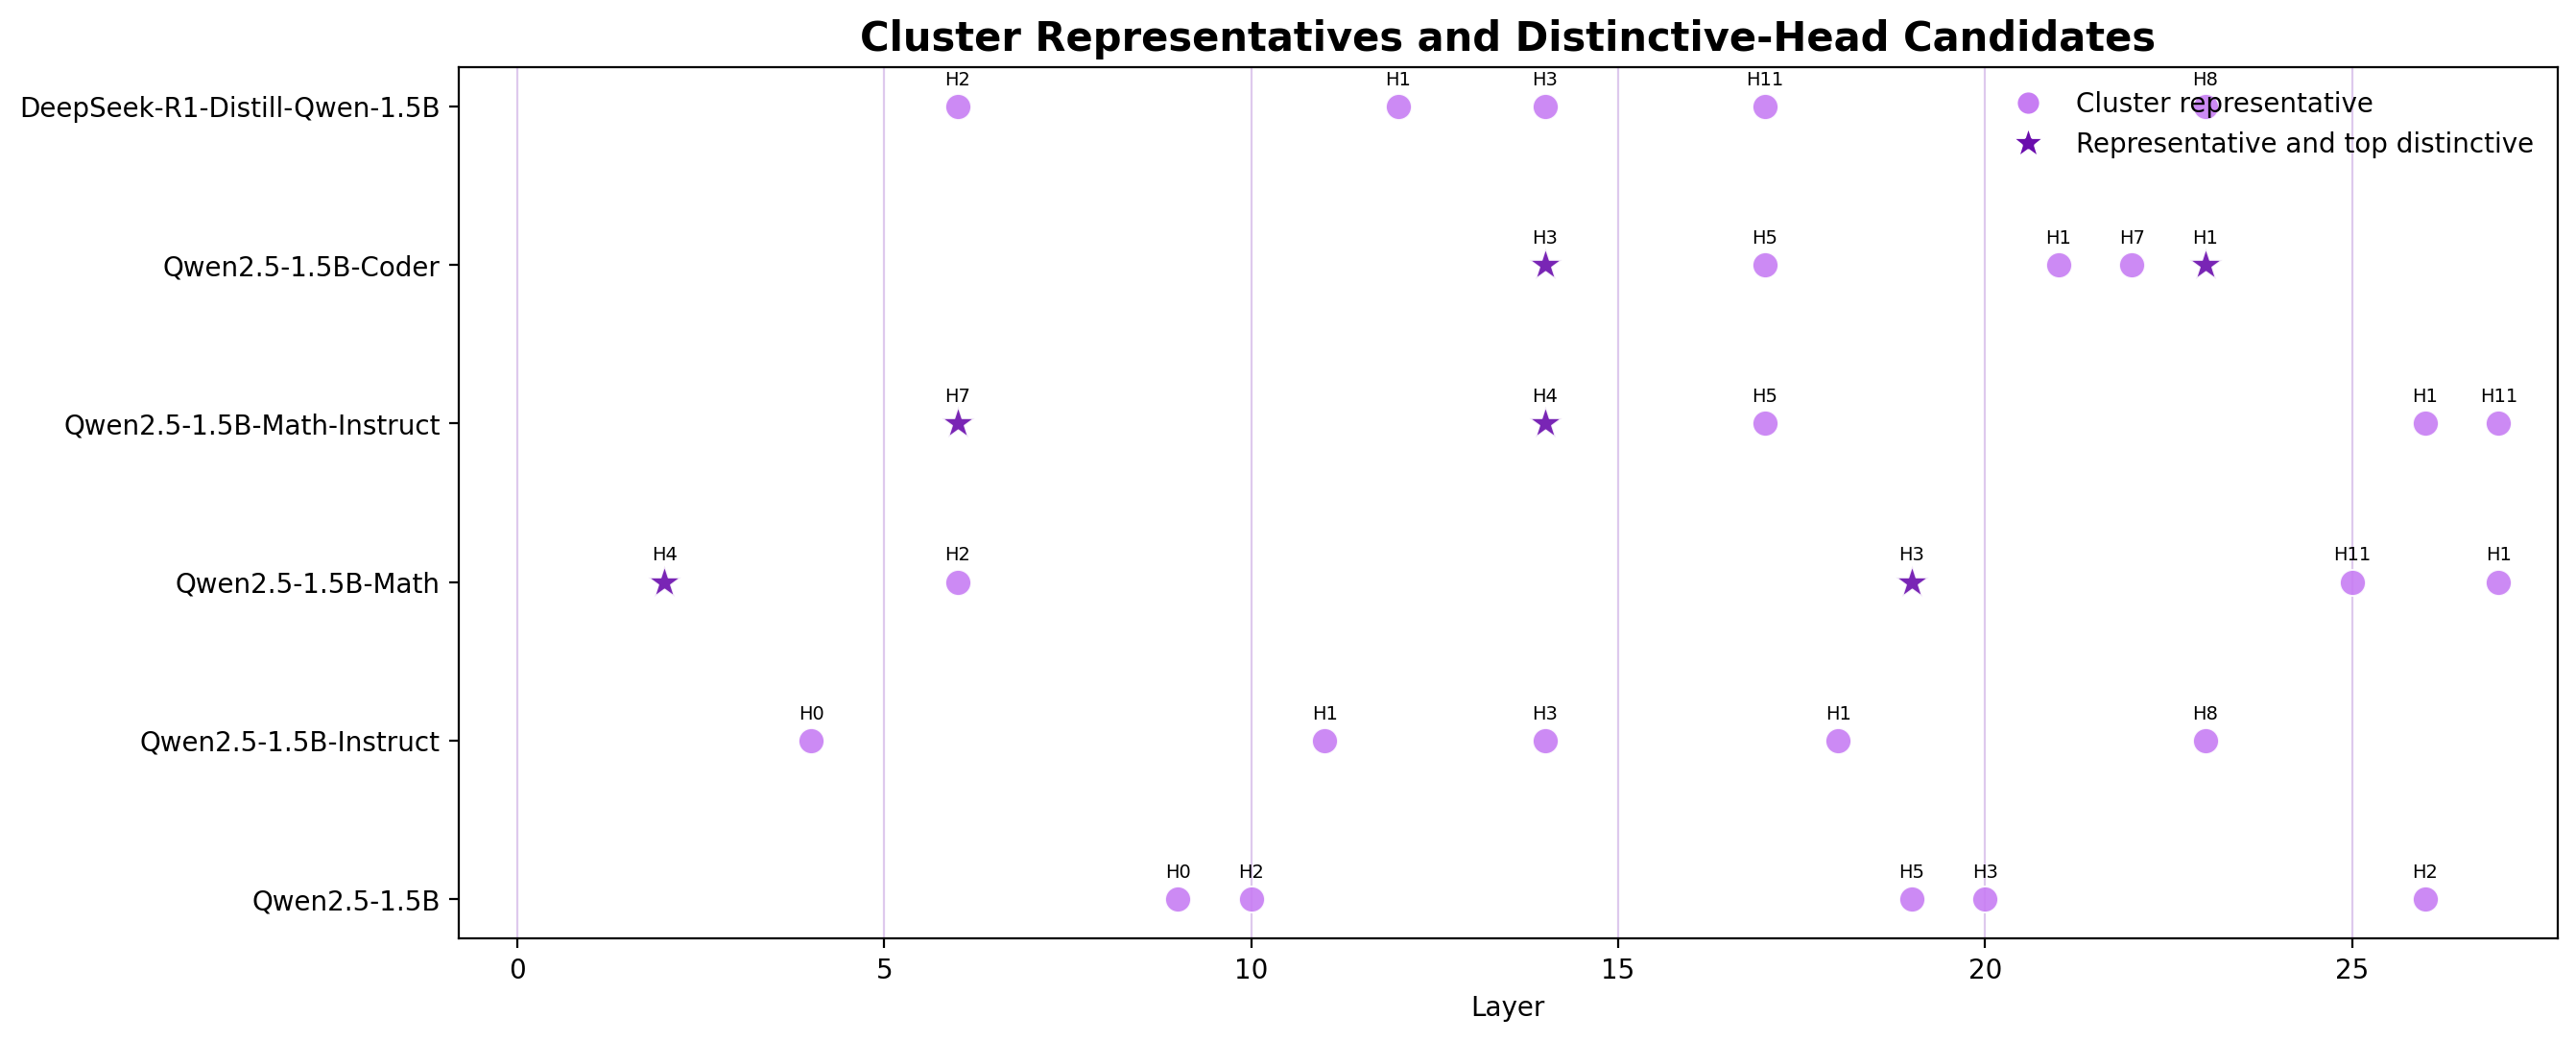

,model_label,cluster,layer,head,also_top_distinctive
25,DeepSeek-R1-Distill-Qwen-1.5B,0,14,3,False
26,DeepSeek-R1-Distill-Qwen-1.5B,1,12,1,False
27,DeepSeek-R1-Distill-Qwen-1.5B,2,23,8,False
28,DeepSeek-R1-Distill-Qwen-1.5B,3,6,2,False
29,DeepSeek-R1-Distill-Qwen-1.5B,4,17,11,False
0,Qwen2.5-1.5B,0,19,5,False
1,Qwen2.5-1.5B,1,20,3,False
2,Qwen2.5-1.5B,2,10,2,False
3,Qwen2.5-1.5B,3,26,2,False
4,Qwen2.5-1.5B,4,9,0,False


In [6]:
representatives_by_model = {
    row['model_label']: row['representatives']
    for _, row in model_df.iterrows()
}
distinctive_records_by_model = {
    label: result['top_records']
    for label, result in comparison_results.items()
}
rep_result = visualize_representative_head_candidates(
    representatives_by_model,
    distinctive_records_by_model=distinctive_records_by_model,
    model_order=ORDERED_LABELS,
    title='Cluster Representatives and Distinctive-Head Candidates',
    output_dir=USECASE_OUTPUT_DIR,
    filename='representative_head_candidates.png',
    max_distinctive_rank=12,
)

display(Image(filename=rep_result['output_path'], width=1000))
rep_df = pd.DataFrame(rep_result['rows'])
display(rep_df.sort_values(['model_label', 'cluster']))


## 6. Long-Context Attention Matrix Comparison

After selecting candidate heads, inspect concrete attention matrices with the standard IzzyViz long-context view.

This example compares the same head, `L23H4`, for the base model and the most different model from the feature-vector ranking. The function used here is:

`visualize_attention_matrix(..., merge_virtual_tokens=True)`

Virtual-token merging keeps the long context readable while preserving the strongest token-level structures.

### Qwen2.5-1.5B: L23 H4

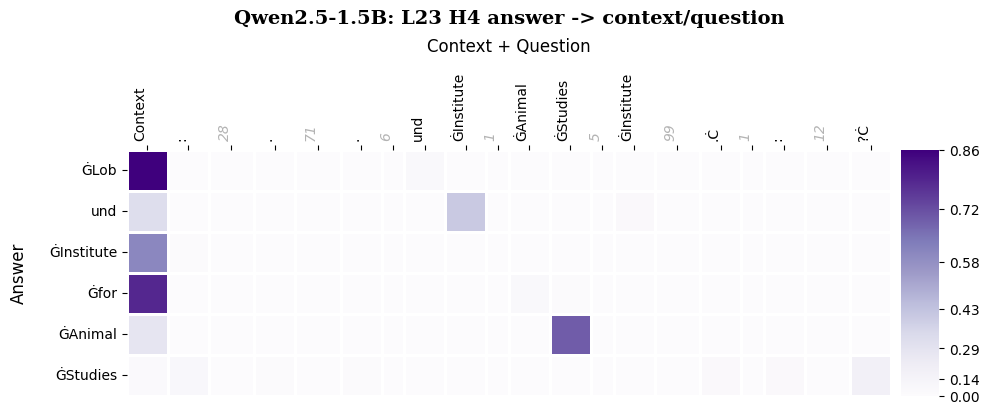

### Qwen2.5-1.5B-Math-Instruct: L23 H4

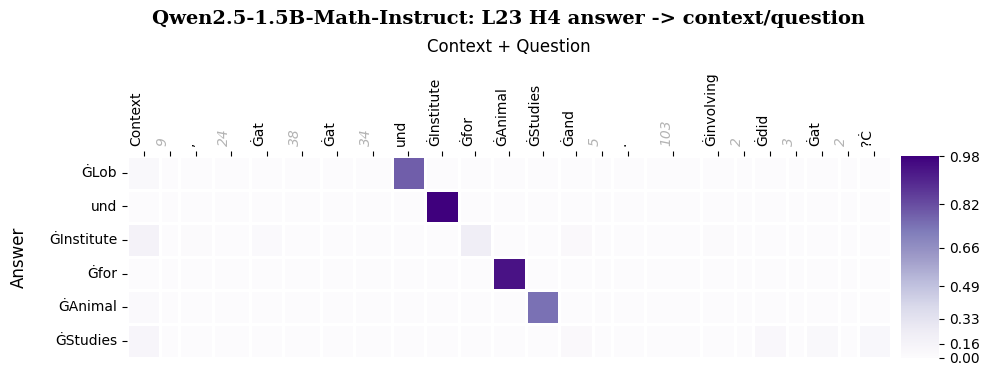

In [7]:
LONG_CONTEXT_OUTPUT_DIR = USECASE_OUTPUT_DIR / 'long_context_attention_L23H4'
LONG_CONTEXT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LAYER_TO_COMPARE = 23
HEAD_TO_COMPARE = 4
TARGET_LONG_CONTEXT_MODEL = comparison_df.iloc[0]['model_label']
LONG_CONTEXT_MODELS = [BASE_MODEL, TARGET_LONG_CONTEXT_MODEL]

long_context_paths = {
    label: LONG_CONTEXT_OUTPUT_DIR / f"{safe_name(label)}_L{LAYER_TO_COMPARE}_H{HEAD_TO_COMPARE}_long_context.png"
    for label in LONG_CONTEXT_MODELS
}

if not all(path.exists() for path in long_context_paths.values()):
    import gc
    import os
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')
    os.environ.setdefault('USE_TF', '0')
    os.environ.setdefault('TRANSFORMERS_NO_TF', '1')
    os.environ.setdefault('USE_FLAX', '0')
    os.environ.setdefault('TRANSFORMERS_NO_FLAX', '1')
    os.environ.setdefault('TRANSFORMERS_NO_TORCHVISION', '1')

    MODEL_IDS = dict(zip(model_df['model_label'], model_df['model_id']))
    BASE_CONTEXT = (
        "The Rev. John J. Cavanaugh, C.S.C. served as president from 1946 to 1952. "
        "Cavanaugh's legacy at Notre Dame in the post-war years was devoted to raising academic standards "
        "and reshaping the university administration to suit it to an enlarged educational mission and an expanded "
        "student body and stressing advanced studies and research at a time when Notre Dame quadrupled in student census, "
        "undergraduate enrollment increased by more than half, and graduate student enrollment grew fivefold. "
        "Cavanaugh also established the Lobund Institute for Animal Studies and Notre Dame's Medieval Institute. "
        "Cavanaugh also presided over the construction of the Nieuwland Science Hall, Fisher Hall, and the Morris Inn, "
        "as well as the Hall of Liberal Arts (now O'Shaughnessy Hall), made possible by a donation from I.A. O'Shaughnessy, "
        "at the time the largest ever made to an American Catholic university. "
        "Cavanaugh also established a system of advisory councils at the university, which continue today and are vital "
        "to the university's governance and development."
    )
    QUESTION = 'Which institute involving animal life did Cavanaugh create at Notre Dame?'
    ANSWER = 'Lobund Institute for Animal Studies'

    def model_dtype():
        if not torch.cuda.is_available():
            return torch.float32
        if torch.cuda.is_bf16_supported():
            return torch.bfloat16
        return torch.float16

    def build_prompt():
        x_text = f'Context: {BASE_CONTEXT}\nQuestion: {QUESTION}\n'
        answer_prefix = 'Answer:'
        prompt = x_text + answer_prefix + f' {ANSWER}'
        return prompt, x_text, answer_prefix

    for label in LONG_CONTEXT_MODELS:
        if long_context_paths[label].exists():
            continue
        model_id = MODEL_IDS[label]
        print('Computing long-context attention:', label, model_id)
        tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
        load_kwargs = dict(
            torch_dtype=model_dtype(),
            attn_implementation='eager',
            trust_remote_code=True,
        )
        if torch.cuda.is_available():
            load_kwargs['device_map'] = 'auto'
        model = AutoModelForCausalLM.from_pretrained(model_id, **load_kwargs)
        model.eval()

        prompt, x_text, answer_prefix = build_prompt()
        inputs = tokenizer(prompt, return_tensors='pt', add_special_tokens=False)
        first_device = next(model.parameters()).device
        inputs = {key: value.to(first_device) for key, value in inputs.items()}
        tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
        x_end = len(tokenizer(x_text, add_special_tokens=False)['input_ids'])
        answer_start = len(tokenizer(x_text + answer_prefix, add_special_tokens=False)['input_ids'])
        answer_end = len(tokens)

        with torch.no_grad():
            outputs = model(
                **inputs,
                output_attentions=True,
                return_dict=True,
                use_cache=False,
            )
        matrix = outputs.attentions[LAYER_TO_COMPARE][0, HEAD_TO_COMPARE, answer_start:answer_end, :x_end].detach().float().cpu().numpy()
        visualize_attention_matrix(
            matrix,
            x_labels=tokens[:x_end],
            y_labels=tokens[answer_start:answer_end],
            title=f'{label}: L{LAYER_TO_COMPARE} H{HEAD_TO_COMPARE} answer -> context/question',
            xlabel='Context + Question',
            ylabel='Answer',
            top_n=20,
            merge_virtual_tokens=True,
            save_path=str(long_context_paths[label]),
            close_after_save=True,
            length_threshold=64,
            if_interval=False,
            if_top_cells=True,
            show_scores_in_enlarged_cells=False,
            lean_more=True,
        )
        del outputs, model, tokenizer, inputs
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

for label, path in long_context_paths.items():
    display(Markdown(f'### {label}: L{LAYER_TO_COMPARE} H{HEAD_TO_COMPARE}'))
    display(Image(filename=str(path), width=1050))


## 7. Notes for Paper Observations

Use this section to refine paper text after inspecting the figures.

### Observation: base vs instruct

The attention overview of Qwen2.5-1.5B is visually similar to Qwen2.5-1.5B-Instruct. The same-head feature distance table provides quantitative support: if Instruct has low mean same-head distance relative to other variants, this supports the claim that instruction tuning preserves much of the global attention topology.

### Observation: math tuning

If Math and Math-Instruct have larger same-head distances than Instruct, that supports the hypothesis that domain-specific mathematical tuning reshapes attention behavior more strongly than instruction tuning alone.

### Observation: distilled model

If DeepSeek-R1-Distill-Qwen-1.5B has the highest mean/max same-head feature distance and several top distinctive heads in low layers, this supports the observation that distillation changes early-stage information routing. Unlike an early/middle/late thumbnail heuristic, this claim is grounded in specific layer/head feature-vector differences.

### Observation: coder model

If Coder has moderate or low same-head distances while its overview remains visually similar to the base model, this supports the hypothesis that coding specialization may rely less on large-scale attention-topology changes and more on other model components or localized changes.

### Observation: shared attention fingerprint

Recurring overview structures and repeated representative-head layer bands across variants suggest a shared Qwen-family attention fingerprint. Distinctive selection highlights local deviations from that shared structure.

### TODO: Manual notes

- TODO: Add exact layer/head examples from the final heatmaps.
- TODO: Compare whether top distinctive heads overlap with clustering representatives.
- TODO: Decide which model-pair heatmaps are strong enough for the demo paper figure.